# Model II Comparison

Compare Random Forest, XGBoost, and LSTM results for Douala and Maroua using the realistic Model II feature set.

Run `Model_training_Douala_Model_II.ipynb` and `Model_training_Maroua_Model_II.ipynb` first to generate the results CSV files.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

## Load Results

In [2]:
douala_results = pd.read_csv("results_douala_model_ii.csv")
maroua_results = pd.read_csv("results_maroua_model_ii.csv")

results = pd.concat(
    [douala_results, maroua_results],
    ignore_index=True
)

results

,City,Model,MAE,RMSE,R2
0,Douala,Random Forest,24.806424,54.715285,0.947625
1,Douala,XGBoost,24.832766,53.323236,0.950256
2,Douala,LSTM,28.580614,56.796212,0.943418
3,Maroua,Random Forest,26.530060,61.108857,0.964619
4,Maroua,XGBoost,26.545543,60.195426,0.965669
5,Maroua,LSTM,42.401357,74.166338,0.950014


## Metric Comparisons

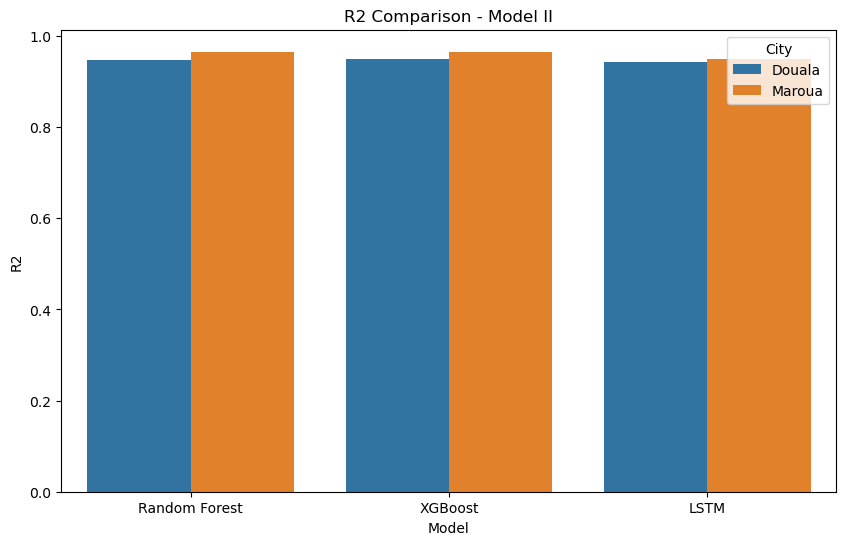

In [3]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="R2",
    hue="City"
)

plt.title("R2 Comparison - Model II")
plt.show()

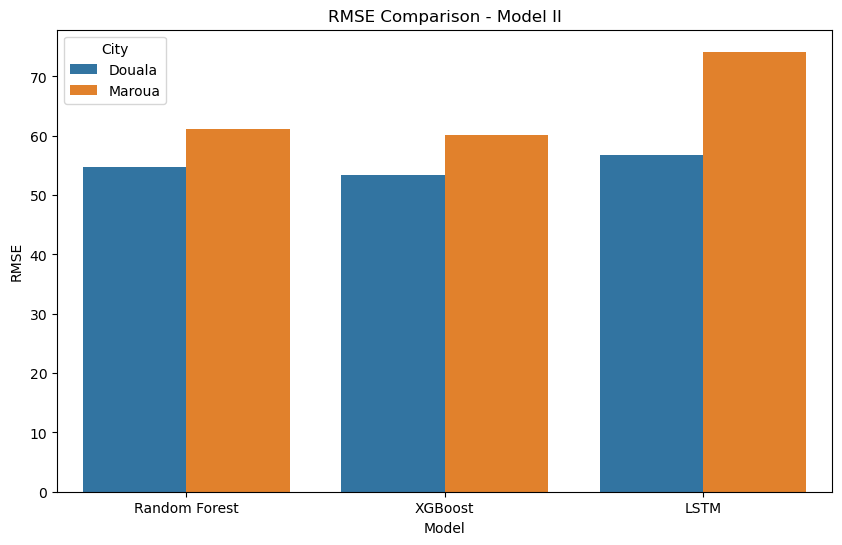

In [4]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE",
    hue="City"
)

plt.title("RMSE Comparison - Model II")
plt.show()

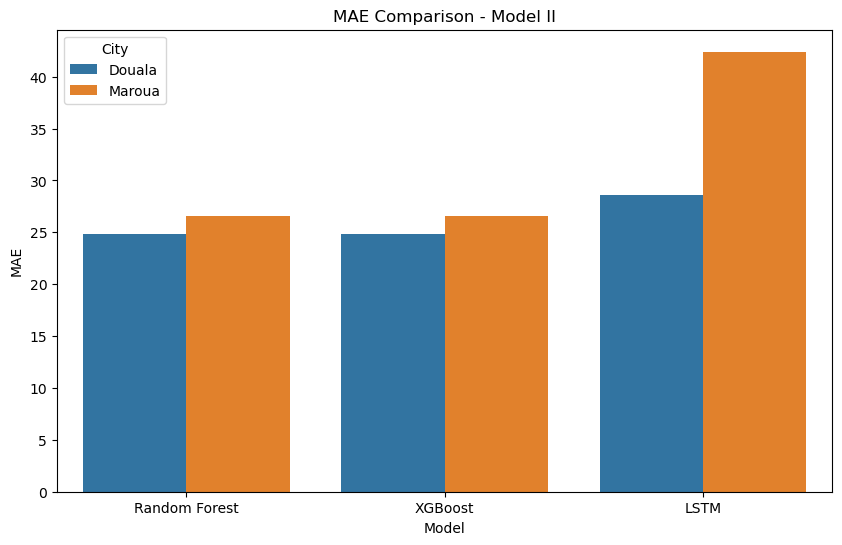

In [5]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="MAE",
    hue="City"
)

plt.title("MAE Comparison - Model II")
plt.show()

## Best Model per City

In [6]:
best_douala = results[
    results["City"] == "Douala"
].sort_values(
    by="R2",
    ascending=False
)

best_douala.head(1)

,City,Model,MAE,RMSE,R2
1,Douala,XGBoost,24.832766,53.323236,0.950256


In [7]:
best_maroua = results[
    results["City"] == "Maroua"
].sort_values(
    by="R2",
    ascending=False
)

best_maroua.head(1)

,City,Model,MAE,RMSE,R2
4,Maroua,XGBoost,26.545543,60.195426,0.965669


## Overall Ranking

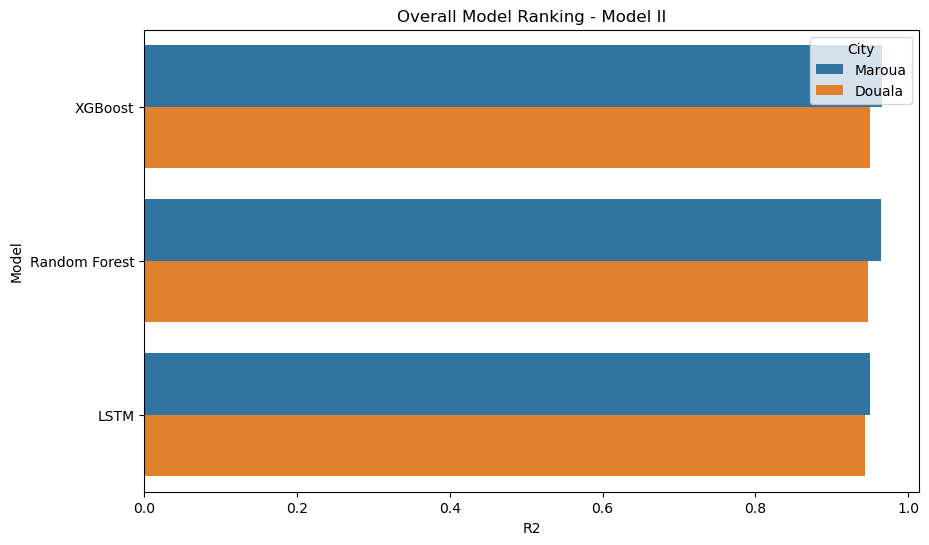

In [8]:
ranking = results.sort_values(
    by="R2",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=ranking,
    x="R2",
    y="Model",
    hue="City"
)

plt.title("Overall Model Ranking - Model II")
plt.show()

In [9]:
overall_best = results.sort_values(by="R2", ascending=False).head(1)

print("Best Model for Douala")
print(best_douala.head(1))

print("\nBest Model for Maroua")
print(best_maroua.head(1))

print("\nOverall Best Model")
print(overall_best)

Best Model for Douala
     City    Model        MAE       RMSE        R2
1  Douala  XGBoost  24.832766  53.323236  0.950256

Best Model for Maroua
     City    Model        MAE       RMSE        R2
4  Maroua  XGBoost  26.545543  60.195426  0.965669

Overall Best Model
     City    Model        MAE       RMSE        R2
4  Maroua  XGBoost  26.545543  60.195426  0.965669


## Summary Table

In [10]:
summary = pd.DataFrame({
    "City": ["Douala", "Maroua", "Overall"],
    "Best Model": [
        best_douala.iloc[0]["Model"],
        best_maroua.iloc[0]["Model"],
        overall_best.iloc[0]["Model"]
    ],
    "MAE": [
        best_douala.iloc[0]["MAE"],
        best_maroua.iloc[0]["MAE"],
        overall_best.iloc[0]["MAE"]
    ],
    "RMSE": [
        best_douala.iloc[0]["RMSE"],
        best_maroua.iloc[0]["RMSE"],
        overall_best.iloc[0]["RMSE"]
    ],
    "R2": [
        best_douala.iloc[0]["R2"],
        best_maroua.iloc[0]["R2"],
        overall_best.iloc[0]["R2"]
    ]
})

summary.to_csv("model_ii_comparison_summary.csv", index=False)
summary

,City,Best Model,MAE,RMSE,R2
0,Douala,XGBoost,24.832766,53.323236,0.950256
1,Maroua,XGBoost,26.545543,60.195426,0.965669
2,Overall,XGBoost,26.545543,60.195426,0.965669
